# Lab 9 Report: 
## Final Project Codebase

## Project Title: Same as your poster title

### Group Members: Simon Harty 

--------------------

In [ ]:
from torchvision import transforms
from torchvision.models.vision_transformer import EncoderBlock
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import pandas as pd
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROP_SIZE = 207
INPUT_SIZE = 64
N_WORKERS = 0
RUN = True

DEVICE

device(type='cuda')

## Prepare Data

In [2]:
#make a class to transform and organize data
class GalaxyDataset(Dataset):
    def __init__(self, image_paths, labels_csv, transform=None, cache_path=None):
        self.transform = transform

        if cache_path and Path(cache_path).exists():
            cache = torch.load(cache_path, weights_only=False)
            self.images = cache['images']
            self.galaxy_ids = cache['galaxy_ids']
            self.labels_df = cache['labels_df']
            
        else:
            pre = transforms.Compose([
                transforms.CenterCrop(CROP_SIZE),
                transforms.Resize(INPUT_SIZE),
                transforms.ToTensor(),
            ])
            self.galaxy_ids = [int(p.stem) for p in image_paths]
            self.images = torch.stack([pre(Image.open(p).convert("RGB")) for p in tqdm.tqdm(image_paths)]).half()
            self.labels_df = pd.read_csv(labels_csv, index_col="GalaxyID")

            if cache_path:
                torch.save({'images': self.images,
                            'galaxy_ids': self.galaxy_ids,
                            'labels_df': self.labels_df},
                            cache_path)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        label_values = self.labels_df.loc[self.galaxy_ids[idx]].values
        label = torch.tensor(label_values, dtype=torch.float32, device=img.device)

        return img, label
    
    def __len__(self):
        return len(self.images)

In [ ]:
data_dir   = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_training_rev1")
labels_csv = r"C:\Users\harty\Code\Galaxy-Classifier\Data\training_solutions_rev1.csv"
all_paths  = sorted(data_dir.glob("*.jpg"))

indices = torch.randperm(len(all_paths), generator=torch.Generator().manual_seed(42))
n_val   = int(len(all_paths) * 0.1)

train_paths = [all_paths[i] for i in indices[n_val:]]
val_paths   = [all_paths[i] for i in indices[:n_val]]

In [ ]:
# load training data to compute average and stdev
train_set = GalaxyDataset(train_paths, labels_csv, transform=None, cache_path='train_set.pth')

# get averages and stdevs for each color in the image
train_mean = train_set.images.mean(dim=[0, 2, 3]).tolist()
train_std = train_set.images.std(dim=[0, 2, 3]).tolist()

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(0, 360)),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# use training means and stds to treat val data as 'unseen'
# do not randomly rotate the validation data for the same reason
val_transform = transforms.Compose([
    transforms.Normalize(mean=train_mean, std=train_std),
])

train_set = GalaxyDataset(train_paths, labels_csv,
                          transform=train_transform,
                          cache_path='train_set.pth')
val_set = GalaxyDataset(val_paths, labels_csv,
                        transform=val_transform,
                        cache_path='val_set.pth')

train_set.images = train_set.images.to(DEVICE)
val_set.images = val_set.images.to(DEVICE)

In [ ]:
print(train_mean, train_std)
print(train_set.__len__(), val_set.__len__())

[0.10345458984375, 0.08953857421875, 0.0703125] [0.1444091796875, 0.1209716796875, 0.10443115234375]
55421 6157


## Define Model

In [ ]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    """Two conv layers with BN, ReLU, and MaxPool."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.block(x)


class ConvTokenizer(nn.Module):
    """Projects feature map into a sequence of tokens for the transformer."""
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x


class CvTBlock(nn.Module):
    """Uses PyTorch's native, optimized Vision Transformer block."""
    def __init__(self, embed_dim, num_heads, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        
        # PyTorch calculates the hidden MLP dimension directly using mlp_dim
        mlp_dim = int(embed_dim * mlp_ratio)
        
        # Native block combines LayerNorm, MultiheadAttention, and the MLP
        self.transformer_layer = EncoderBlock(
            num_heads=num_heads,
            hidden_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            attention_dropout=dropout,
            norm_layer=nn.LayerNorm
        )

    def forward(self, x):
        return self.transformer_layer(x)


class GalaxyClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        num_outputs: int = 37,
        conv_channels: int = 48,
        embed_dim: int = 48,
        num_heads: int = 3,
        num_cvt_layers: int = 2,
        fc_dim: int = 256,
        dropout: float = 0.4,
    ):
        super().__init__()

        # CNN block
        self.conv_block = ConvBlock(in_channels, conv_channels)

        # CvT block
        self.tokenizer = ConvTokenizer(conv_channels, embed_dim)
        self.cvt = nn.Sequential(
            *[CvTBlock(embed_dim, num_heads, dropout=dropout)
              for _ in range(num_cvt_layers)]
        )

        # FC layers
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim, fc_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim // 2, num_outputs),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.tokenizer(x)
        x = self.cvt(x)
        x = x.mean(dim=1)
        x = self.fc(x)  
        return x


model = GalaxyClassifier().to(DEVICE)

dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}")   # expect [4, 37]
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([4, 37])
Params: 34,757


c:\Users\harty\miniconda3\envs\torchtext\Lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


## Define Hyperparameters

In [ ]:
BATCH_SIZE = 64
EPOCHS = 24
LR = 1e-3
WD = 1e-2

optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)
loss_func = torch.nn.MSELoss()

## Identify Tracked Values

In [ ]:
train_losses = []
val_losses = []

## Train Model

In [ ]:
from torch.utils.data import Subset
num_batches = 160

if RUN == True:
    train_subset = Subset(train_set, range(BATCH_SIZE*num_batches))
    val_subset = Subset(val_set, range(BATCH_SIZE*(num_batches // 2)))
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS)
    val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)
    scaler = torch.amp.GradScaler(device='cuda')

    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in tqdm.trange(EPOCHS):
        model.train()
        running_loss = 0

        for imgs, labels in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(imgs)
                loss = loss_func(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)

        train_losses.append((running_loss / len(train_subset)) ** 0.5)

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(imgs)
                    loss = loss_func(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                
            val_losses.append((running_loss / len(val_subset)) ** 0.5)


  0%|          | 0/20 [00:00<?, ?it/s]c:\Users\harty\miniconda3\envs\torchtext\Lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 20/20 [28:50<00:00, 86.50s/it]


In [10]:
torch.save({'model_state_dict': model.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses},
            f"model_{val_losses[-1]:.3f}.pth")

## Visualize & Evaluate Model

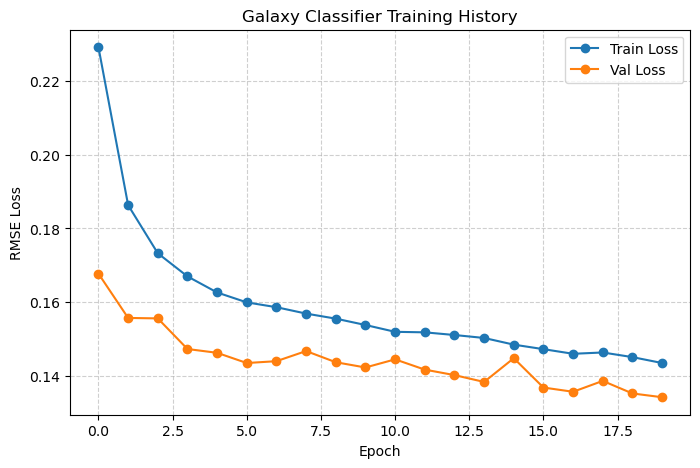

In [12]:
r'''
import torch
import matplotlib.pyplot as plt

model = GalaxyClassifier().to(DEVICE)

# load saved model
checkpoint_path = r"model_0.134.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

# get losses and model from file
model.load_state_dict(checkpoint['model_state_dict'])
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']

# eval mode
model.eval()

# plot
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("RMSE Loss")
plt.title("Galaxy Classifier Training History")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
'''

★ High-Resolution Mosaic Completed with Large Header Font


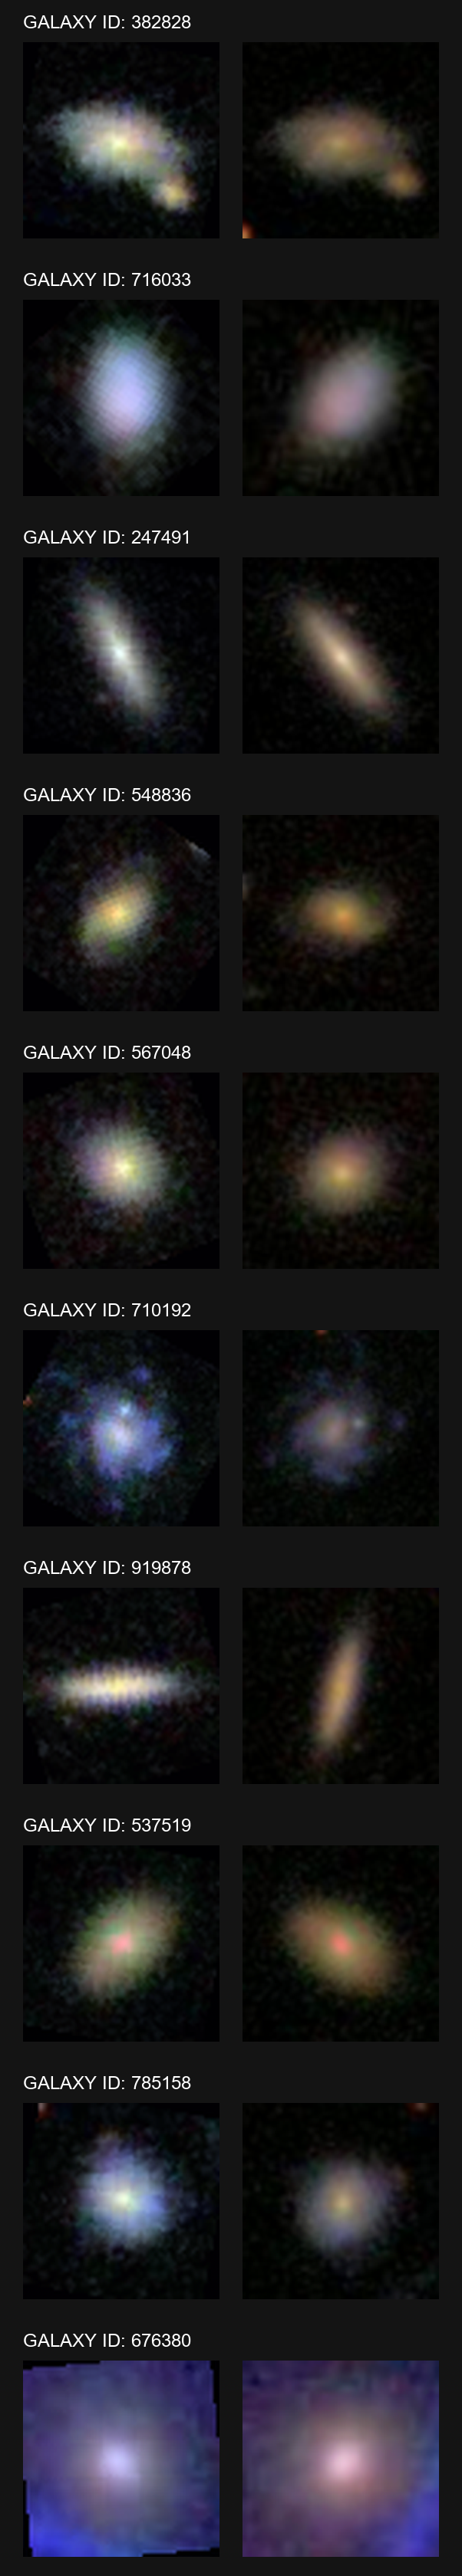

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import numpy as np

n_disp = 10

# --- HIGH RESOLUTION CONFIGURATION (DPI INCREASE) ---
img_w, img_h = 256, 256  

# Calculate canvas dimensions
mosaic_w = (img_w * 2) + 90  # Width: Left Image + Center Gap + Right Image + Margins
row_total_h = img_h + 80     # Extra vertical room for the large text + margins
mosaic_h = row_total_h * n_disp

# Initialize a large high-res RGB canvas sheet
mosaic_canvas = Image.new("RGB", (mosaic_w, mosaic_h), (20, 20, 20))
draw = ImageDraw.Draw(mosaic_canvas)

# --- FONT ADJUSTMENT: Load standard Windows Arial font with a large 24pt scale ---
try:
    # Uses the font directly from the Windows Fonts directory
    font = ImageFont.truetype("arial.ttf", 24)
except IOError:
    # Fallback to default if the file is completely missing
    font = ImageFont.load_default()

for idx in range(n_disp):
    # Calculate starting vertical block layout coordinate
    row_start_y = idx * row_total_h
    
    # Fetch data objects
    img_tensor, label = train_set[idx]
    galaxy_id = train_set.galaxy_ids[idx]
    
    # -------------------------------------------------------------------------
    # 1. DRAW TEXT: Large ID placed cleanly over the top of the row
    # -------------------------------------------------------------------------
    text_str = f"GALAXY ID: {galaxy_id}"
    text_y = row_start_y + 15
    text_x = 30 # Aligns the text left with the edge of the first image column
    
    draw.text((text_x, text_y), text_str, fill=(255, 255, 255), font=font)
    
    # Image row baseline placement point (shifted down for the larger text layout)
    image_y = row_start_y + 55
    
    # -------------------------------------------------------------------------
    # 2. GENERATE LEFT IMAGE: Processed (Rotated & Normalized)
    # -------------------------------------------------------------------------
    img_numpy = img_tensor.permute(1, 2, 0).float().cpu().numpy()
    img_min, img_max = img_numpy.min(), img_numpy.max()
    img_scaled = (img_numpy - img_min) / (img_max - img_min + 1e-8)
    
    left_bytes = (img_scaled * 255).astype(np.uint8)
    left_pil = Image.fromarray(left_bytes)
    
    # HIGH-DPI UP-SAMPLING: Stretch the image cleanly with anti-aliasing
    left_pil_resized = left_pil.resize((img_w, img_h), Image.Resampling.LANCZOS)
    mosaic_canvas.paste(left_pil_resized, (30, image_y))
    
    # -------------------------------------------------------------------------
    # 3. GENERATE RIGHT IMAGE: Clean Cached Original Shape
    # -------------------------------------------------------------------------
    raw_tensor = train_set.images[idx]
    right_numpy = (raw_tensor.float().permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    right_pil = Image.fromarray(right_numpy)
    
    # HIGH-DPI UP-SAMPLING: Match the size of the processed column cleanly
    right_pil_resized = right_pil.resize((img_w, img_h), Image.Resampling.LANCZOS)
    mosaic_canvas.paste(right_pil_resized, (img_w + 60, image_y))

# -------------------------------------------------------------------------
# 4. DISPLAY THE HIGH-DPI SHEET
# -------------------------------------------------------------------------
print("Processed | Original")
display(mosaic_canvas)